# Semana 3 — Optimización con Transfer Learning e Interpretabilidad
## Monitoreo de Seguridad en el Lugar de Trabajo

**Asignatura:** Aprendizaje Profundo — MIA-B  
**Docente:** Jeferson Rodríguez Chivata  
**Universidad:** UIDE  
**Grupo 1:**
- César Nelson Abarca Araujo
- Iván Mauricio Ortega Chapaca
- Jhon Enrique Oña Guamaní

**Fecha:** 1 de junio del 2026

---

## Descripción del Proyecto

Este notebook extiende el trabajo de la **Semana 2** (CNN desde cero + TL con MobileNetV2 congelado) implementando:
1. Fine-Tuning real con descongelamiento parcial del backbone
2. Optimización de hiperparámetros con callbacks avanzados
3. Técnicas de Interpretabilidad (Grad-CAM++) sobre las predicciones
4. Análisis comparativo formal contra los resultados de Semana 2

**Dataset:** Worksite Safety Monitoring Dataset — clasificación binaria `safe` / `unsafe`  
- Train: 810 safe + 810 unsafe  
- Validation: 100 safe + 100 unsafe  
- Test: 100 safe + 100 unsafe

---
## Sección 1 — Selección y Justificación del Modelo Pre-entrenado (1.5 pts)

### 1.1 Backbone elegido: **EfficientNetV2B0**

#### ¿Por qué EfficientNetV2B0?

| Criterio | Detalle |
|---|---|
| **Arquitectura original** | Familia EfficientNet V2 (Tan & Le, 2021) — scaling compuesto de profundidad, anchura y resolución |
| **Entrenado en** | ImageNet-21k + ImageNet-1k (1.28 M imágenes, 1000 clases) |
| **Parámetros** | ~7.2 M (muy eficiente frente a VGG16 ~138 M o ResNet50 ~25 M) |
| **Resolución de entrada** | 224 × 224 px |
| **Precisión ImageNet Top-1** | ~77.1% (B0) hasta ~87% (L) |

#### Vínculo con el problema de seguridad laboral

EfficientNetV2B0 extrae representaciones visuales muy ricas de objetos y texturas de escenas cotidianas (ImageNet incluye equipamiento, personas y espacios industriales), lo que lo hace **pertinente** para discriminar entre:
- **safe**: trabajadores con EPP visible (cascos, chalecos)
- **unsafe**: ausencia de equipamiento o posturas de riesgo

Su tamaño compacto permite fine-tuning eficiente sobre el dataset relativamente pequeño (810 imágenes por clase) **sin riesgo severo de sobreajuste**, a diferencia de backbones más grandes como ResNet101 o VGG16.

#### Por qué **no** se eligieron otras alternativas
- **MobileNetV2** (Semana 2): demostró accuracy ~76.5% sin fine-tuning real; límite de capacidad identificado
- **VGG16**: 138 M parámetros — excessivo para el tamaño del dataset; riesgo de overfitting
- **ResNet50**: mayor accuracy pero 3× más parámetros que EfficientNetV2B0; convergencia más lenta

---
## Sección 2 — Adaptación del Dataset y Ficha Técnica (1.0 pt)

### 2.1 Ajustes de entrada para EfficientNetV2B0

| Transformación | Valor | Justificación |
|---|---|---|
| **Redimensionado** | 224 × 224 px | Resolución estándar EfficientNetV2B0 |
| **Normalización** | `tf.keras.applications.efficientnet_v2.preprocess_input` | Escala [0,255] → [-1,1], coherente con ImageNet |
| **Canales** | RGB (3 canales) | Dataset ya en color; sin conversión requerida |
| **Batch size** | 32 | Balance memoria/velocidad de convergencia |

### 2.2 Ficha técnica del dataset

| Split | safe | unsafe | Total |
|---|---|---|---|
| Train | 810 | 810 | **1620** |
| Validation | 100 | 100 | **200** |
| Test | 100 | 100 | **200** |
| **Total** | **1010** | **1010** | **2020** |

> El dataset está **perfectamente balanceado** (50% / 50%), por lo que class_weight uniforme es el punto de partida correcto. Si el modelo aún muestra recall bajo en `unsafe`, se aplicará class_weight ajustado.

### 2.3 Pipeline de datos
- `image_dataset_from_directory` con `label_mode='int'`
- `cache()` + `prefetch(AUTOTUNE)` para eficiencia de I/O
- `shuffle(buffer_size=1000, seed=SEED)` solo en train
- Augmentation integrada como primera capa del modelo (se aplica solo en training)

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURACIÓN GLOBAL
# ─────────────────────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs disponibles: {tf.config.list_physical_devices('GPU')}")

# ─── Semillas de reproducibilidad ───────────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ─── Hiperparámetros globales ────────────────────────────────────────────────
IMG_SIZE      = (224, 224)     # EfficientNetV2B0 standard
BATCH_SIZE    = 32
EPOCHS_FROZEN = 15             # Fase 1: solo cabeza entrenada
EPOCHS_FT     = 20             # Fase 2: fine-tuning capas superiores
LR_FROZEN     = 1e-3           # Alta: backbone congelado, solo cabeza
LR_FINETUNE   = 1e-5           # Muy baja: preservar pesos pre-entrenados
UNFREEZE_FROM = 0.70           # Descongelar el último 30% de capas
AUTOTUNE      = tf.data.AUTOTUNE

# ─── Rutas ──────────────────────────────────────────────────────────────────
BASE_DIR    = r'C:\Users\cabarca2\MAESTRIA_IA\datasets\Worksite-Safety-Monitoring-Dataset'
TRAIN_DIR   = os.path.join(BASE_DIR, 'train')
VAL_DIR     = os.path.join(BASE_DIR, 'valid')
TEST_DIR    = os.path.join(BASE_DIR, 'test')
MODEL_SAVE  = os.path.join(os.path.dirname(os.path.abspath('__file__')),
                           r'4. Aprendizaje Profundo\Semana 3\Deber\modelo_s3_efficientnetv2b0.keras')

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    assert os.path.isdir(d), f"❌ Directorio no encontrado: {d}"
    clases = os.listdir(d)
    for c in clases:
        n = len(os.listdir(os.path.join(d, c)))
        print(f"  {os.path.basename(d)}/{c}: {n} imágenes")

print("\n✅ Rutas verificadas correctamente")

TensorFlow version: 2.21.0
GPUs disponibles: []
  train/safe: 810 imágenes
  train/unsafe: 810 imágenes
  valid/safe: 100 imágenes
  valid/unsafe: 100 imágenes
  test/safe: 100 imágenes
  test/unsafe: 100 imágenes

✅ Rutas verificadas correctamente


Found 1620 files belonging to 2 classes.
Found 200 files belonging to 2 classes.
Found 200 files belonging to 2 classes.
Clases: ['safe', 'unsafe']  |  num_classes = 2


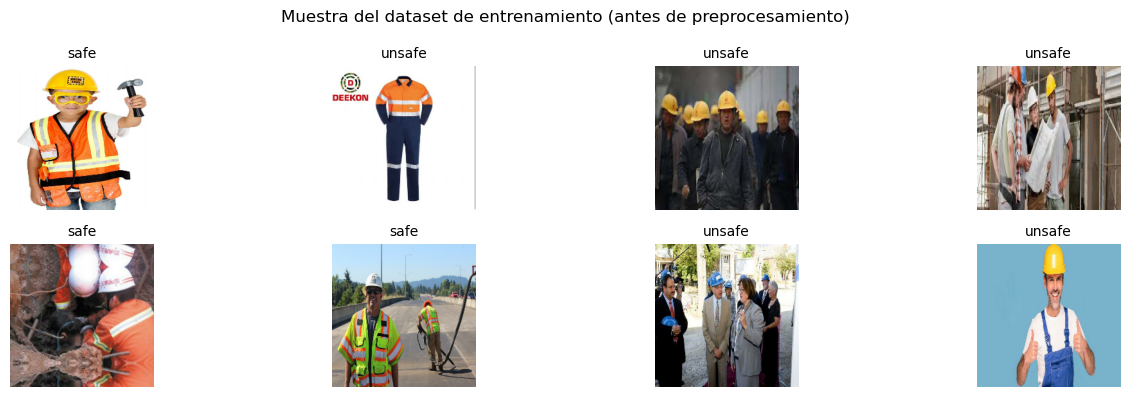

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CARGA DEL DATASET — Pipeline eficiente con cache y prefetch
# ─────────────────────────────────────────────────────────────────────────────
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False  # Sin shuffle para evaluación reproducible
)

class_names = train_ds_raw.class_names
num_classes = len(class_names)
print(f"Clases: {class_names}  |  num_classes = {num_classes}")

# ─── Pipelines optimizados ───────────────────────────────────────────────────
train_ds = (train_ds_raw
            .cache()
            .shuffle(buffer_size=1000, seed=SEED)
            .prefetch(AUTOTUNE))

val_ds  = val_ds_raw.cache().prefetch(AUTOTUNE)
test_ds = test_ds_raw.cache().prefetch(AUTOTUNE)

# ─── Visualización de muestra ────────────────────────────────────────────────
plt.figure(figsize=(14, 4))
for images, labels in train_ds.take(1):
    for i in range(8):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]], fontsize=10)
        plt.axis('off')
plt.suptitle('Muestra del dataset de entrenamiento (antes de preprocesamiento)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Sección 3 — Estrategia de Transfer Learning y Fine-Tuning (2.0 pts)

### 3.1 Arquitectura del modelo

La estrategia sigue **dos fases** (basada en el notebook de referencia `Nb_3a`):

```
Input (224×224×3)
  │
  ├─ [Data Augmentation]  ← solo activo en training
  │   RandomFlip, RandomRotation, RandomZoom, RandomContrast
  │
  ├─ preprocess_input()   ← normalización EfficientNet: [0,255]→[-1,1]
  │
  ├─ EfficientNetV2B0     ← backbone (~7.2 M params)
  │   FASE 1: 100% congelado
  │   FASE 2: último 30% descongelado
  │
  ├─ GlobalAveragePooling2D
  ├─ BatchNormalization
  ├─ Dense(256, relu) + Dropout(0.40)
  ├─ Dense(128, relu) + Dropout(0.25)
  └─ Dense(2, softmax)    ← salida probabilística para 2 clases
```

### 3.2 Estrategia de congelamiento (Freezing)

**Fase 1 (Feature Extraction):**  
- Backbone **100% congelado** — se entrena únicamente la cabeza de clasificación  
- El backbone actúa como extractor de características fijo de ImageNet  
- LR alta (1e-3) porque solo hay ~300k parámetros entrenables en la cabeza

**Fase 2 (Fine-Tuning):**  
- Se descongela el **último 30% de las capas** del backbone  
- Criterio: las capas superiores del backbone aprenden características más específicas (bordes de herramientas, texturas de EPP) que las capas base (detectores de bordes genéricos)  
- LR muy baja (1e-5) para **no destruir** los pesos pre-entrenados  
- Se continúa el entrenamiento desde los mejores pesos de Fase 1

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CONSTRUCCIÓN DEL MODELO — Sección 3
# ─────────────────────────────────────────────────────────────────────────────

def build_augmentation():
    """Capa de aumento de datos más agresiva que Semana 2 para mejorar generalización."""
    return Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.15),
        layers.RandomTranslation(0.1, 0.1),
    ], name='data_augmentation')


def build_model(num_classes=2, trainable_backbone=False):
    """
    Construye el modelo con EfficientNetV2B0 como backbone.
    
    Args:
        num_classes: número de clases de salida
        trainable_backbone: si True, el backbone completo es entrenable (no usar en Fase 1)
    Returns:
        modelo compilado para Fase 1 (backbone congelado)
    """
    # ── Entrada ──────────────────────────────────────────────────────────────
    inputs = keras.Input(shape=IMG_SIZE + (3,), name='input_imagen')
    
    # ── Augmentation (solo en training) ─────────────────────────────────────
    x = build_augmentation()(inputs, training=None)  # training flag controlado por Keras
    
    # ── Preprocesamiento EfficientNet: [0,255] → [-1, 1] ────────────────────
    x = layers.Lambda(lambda img: preprocess_input(img), name='preprocess')(x)
    
    # ── Backbone EfficientNetV2B0 ─────────────────────────────────────────────
    backbone = EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_shape=IMG_SIZE + (3,)
    )
    backbone.trainable = trainable_backbone  # Fase 1: False
    x = backbone(x, training=False)  # BN en modo inferencia aunque model.fit sea llamado
    
    # ── Cabeza de clasificación ───────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dense(256, activation='relu', name='dense_256')(x)
    x = layers.Dropout(0.40, name='drop_256')(x)
    x = layers.Dense(128, activation='relu', name='dense_128')(x)
    x = layers.Dropout(0.25, name='drop_128')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)
    
    model = keras.Model(inputs, outputs, name='EfficientNetV2B0_WorksiteSafety')
    return model, backbone


model, backbone = build_model(num_classes=num_classes, trainable_backbone=False)

# Verificar parámetros
total     = model.count_params()
trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
frozen    = total - trainable
print(f"Total parámetros   : {total:,}")
print(f"Entrenables (Fase1): {trainable:,}  ({100*trainable/total:.1f}%)")
print(f"Congelados         : {frozen:,}  ({100*frozen/total:.1f}%)")
model.summary(expand_nested=False)

Total parámetros   : 6,285,522
Entrenables (Fase1): 363,650  (5.8%)
Congelados         : 5,921,872  (94.2%)


Model: "EfficientNetV2B0_WorksiteSafety"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_imagen (InputLayer)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess (Lambda)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_256 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_128 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,285,522 (23.98 MB)

 Trainable params: 363,650 (1.39 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

---
## Sección 4 — Configuración y Entrenamiento Optimizado (1.0 pt)

### 4.1 Selección de Learning Rate

| Fase | LR | Justificación |
|---|---|---|
| **Fase 1** (backbone congelado) | **1e-3** | Solo la cabeza se entrena; LR alta para convergencia rápida |
| **Fase 2** (fine-tuning) | **1e-5** | LR 100× menor para no destruir representaciones pre-entrenadas |

### 4.2 Optimizador y Función de Pérdida
- **Optimizador:** Adam con `clipnorm=1.0` para evitar explosión de gradientes durante fine-tuning
- **Pérdida:** `SparseCategoricalCrossentropy` (etiquetas enteras, salida softmax)

### 4.3 Callbacks
| Callback | Configuración | Función |
|---|---|---|
| `EarlyStopping` | monitor='val_loss', patience=7, restore_best_weights=True | Detiene si no mejora; restaura mejor estado |
| `ReduceLROnPlateau` | factor=0.3, patience=3, min_lr=1e-7 | Reduce LR dinámicamente si plateau | 
| `ModelCheckpoint` | save_best_only=True | Guarda el mejor modelo localmente |

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# FASE 1 — Feature Extraction (backbone 100% congelado)
# ─────────────────────────────────────────────────────────────────────────────
print("="*65)
print("FASE 1 — Feature Extraction con backbone EfficientNetV2B0 congelado")
print("="*65)

# Nota: Precision/Recall se omiten del compile en TF 2.21/Keras 3 porque
# generan "Incompatible shapes" con batches de distinto tamaño (último batch).
# Se calculan post-entrenamiento con sklearn (más preciso y sin restricciones).
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_FROZEN, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fase1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=3,
        min_lr=1e-7, verbose=1
    ),
]

history_fase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FROZEN,
    callbacks=callbacks_fase1,
    verbose=1
)

val_loss_f1, val_acc_f1 = model.evaluate(val_ds, verbose=0)
print(f"\n✅ Fase 1 finalizada — Val Accuracy: {val_acc_f1:.4f} | Val Loss: {val_loss_f1:.4f}")

FASE 1 — Feature Extraction con backbone EfficientNetV2B0 congelado
Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.6710 - loss: 0.7218 - val_accuracy: 0.7450 - val_loss: 0.5270 - learning_rate: 0.0010
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 48s 945ms/step - accuracy: 0.7444 - loss: 0.5526 - val_accuracy: 0.7450 - val_loss: 0.4864 - learning_rate: 0.0010
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 50s 989ms/step - accuracy: 0.7735 - loss: 0.4958 - val_accuracy: 0.7950 - val_loss: 0.4337 - learning_rate: 0.0010
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 49s 959ms/step - accuracy: 0.7901 - loss: 0.4538 - val_accuracy: 0.8000 - val_loss: 0.4190 - learning_rate: 0.0010
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.8154 - loss: 0.4154 - val_accuracy: 0.8150 - val_loss: 0.3795 - learning_rate: 0.0010
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 50s 987ms/step - accuracy: 0.8315 - loss: 0.3954 - val_accuracy: 0.8350 - val_loss: 0.3728 - learning_rate: 0.0010
Epoch 7/15
51/51 ━━━

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# FASE 2 — Fine-Tuning: descongelar el último 30% del backbone
# ─────────────────────────────────────────────────────────────────────────────
print("="*65)
print("FASE 2 — Fine-Tuning: descongelando capas superiores del backbone")
print("="*65)

# Descongelar el backbone
backbone.trainable = True

# Calcular índice de corte: congelar el primer 70%, descongelar el último 30%
total_layers  = len(backbone.layers)
freeze_until  = int(total_layers * UNFREEZE_FROM)  # índice de corte

for layer in backbone.layers[:freeze_until]:
    layer.trainable = False
for layer in backbone.layers[freeze_until:]:
    layer.trainable = True

# Mantener BatchNorm del backbone en modo inferencia (crítico para fine-tuning)
for layer in backbone.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_ft = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Total capas backbone : {total_layers}")
print(f"Capas congeladas     : {freeze_until}  (primer 70%)")
print(f"Capas descongeladas  : {total_layers - freeze_until}  (último 30%)")
print(f"Parámetros entrenables en Fase 2: {trainable_ft:,}")

# Recompilar con LR muy baja (sin Precision/Recall por bug en Keras 3 con batches variables)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_FINETUNE, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fase2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=3,
        min_lr=1e-8, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=MODEL_SAVE,
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
]

history_fase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    callbacks=callbacks_fase2,
    verbose=1
)

val_loss_f2, val_acc_f2 = model.evaluate(val_ds, verbose=0)
print(f"\n✅ Fase 2 finalizada — Val Accuracy: {val_acc_f2:.4f} | Val Loss: {val_loss_f2:.4f}")

FASE 2 — Fine-Tuning: descongelando capas superiores del backbone
Total capas backbone : 270
Capas congeladas     : 189  (primer 70%)
Capas descongeladas  : 81  (último 30%)
Parámetros entrenables en Fase 2: 3,432,050
Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8589 - loss: 0.3151
Epoch 1: val_accuracy improved from None to 0.83500, saving model to c:\Users\cabarca2\MAESTRIA_IA\4. Aprendizaje Profundo\Semana 3\Deber\4. Aprendizaje Profundo\Semana 3\Deber\modelo_s3_efficientnetv2b0.keras

Epoch 1: finished saving model to c:\Users\cabarca2\MAESTRIA_IA\4. Aprendizaje Profundo\Semana 3\Deber\4. Aprendizaje Profundo\Semana 3\Deber\modelo_s3_efficientnetv2b0.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.8451 - loss: 0.3343 - val_accuracy: 0.8350 - val_loss: 0.3588 - learning_rate: 1.0000e-05
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8924 - loss: 0.2723
Epoch 2: val_accuracy improved from 0.83500 to 0.85000, saving model to c:\Users\cabarc

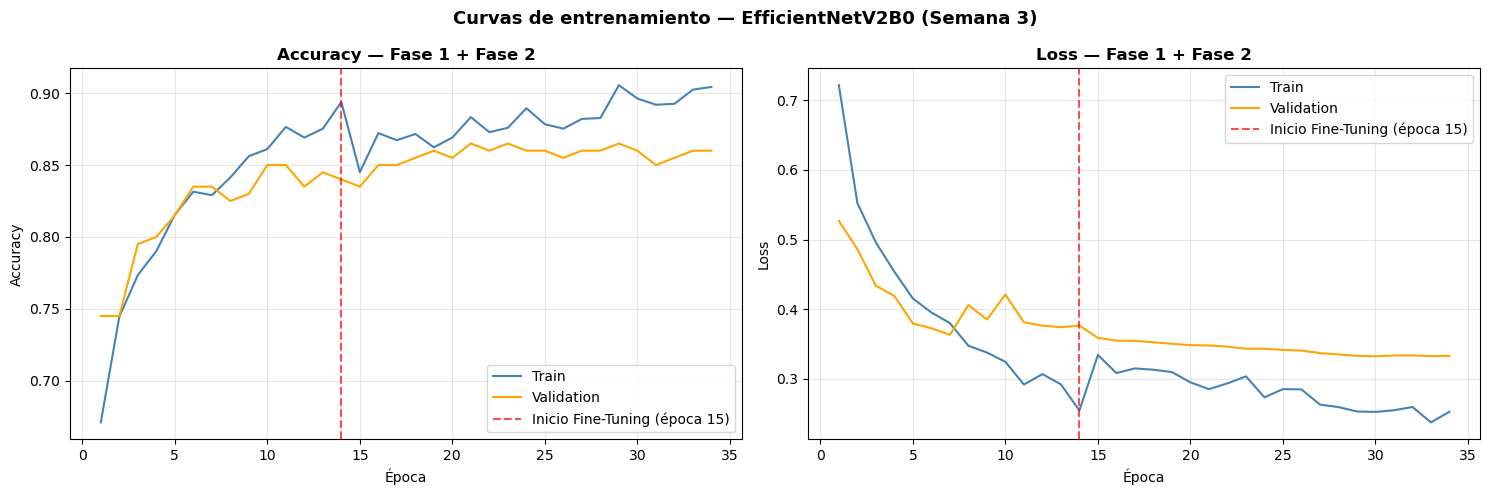

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CURVAS DE ENTRENAMIENTO — Fases 1 y 2 combinadas
# ─────────────────────────────────────────────────────────────────────────────
def plot_training_history(hist1, hist2):
    n1 = len(hist1.history['accuracy'])
    n2 = len(hist2.history['accuracy'])
    epochs_total = n1 + n2
    
    acc     = hist1.history['accuracy']     + hist2.history['accuracy']
    val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    loss    = hist1.history['loss']         + hist2.history['loss']
    val_los = hist1.history['val_loss']     + hist2.history['val_loss']
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    for ax, train_m, val_m, title, ylabel in zip(
        axes,
        [acc, loss],
        [val_acc, val_los],
        ['Accuracy — Fase 1 + Fase 2', 'Loss — Fase 1 + Fase 2'],
        ['Accuracy', 'Loss']
    ):
        ax.plot(range(1, epochs_total+1), train_m, label='Train', color='steelblue')
        ax.plot(range(1, epochs_total+1), val_m,   label='Validation', color='orange')
        ax.axvline(x=n1, color='red', linestyle='--', alpha=0.7, label=f'Inicio Fine-Tuning (época {n1+1})')
        ax.set_xlabel('Época')
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)
    
    plt.suptitle('Curvas de entrenamiento — EfficientNetV2B0 (Semana 3)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_training_history(history_fase1, history_fase2)

EVALUACIÓN FINAL — Conjunto de Test

Test Loss     : 0.3180
Test Accuracy : 0.8650
Test Precision: 0.8668  (macro, sklearn)
Test Recall   : 0.8650  (macro, sklearn)

Informe de Clasificación (Test Set):
              precision    recall  f1-score   support

        safe       0.84      0.90      0.87       100
      unsafe       0.89      0.83      0.86       100

    accuracy                           0.86       200
   macro avg       0.87      0.86      0.86       200
weighted avg       0.87      0.86      0.86       200



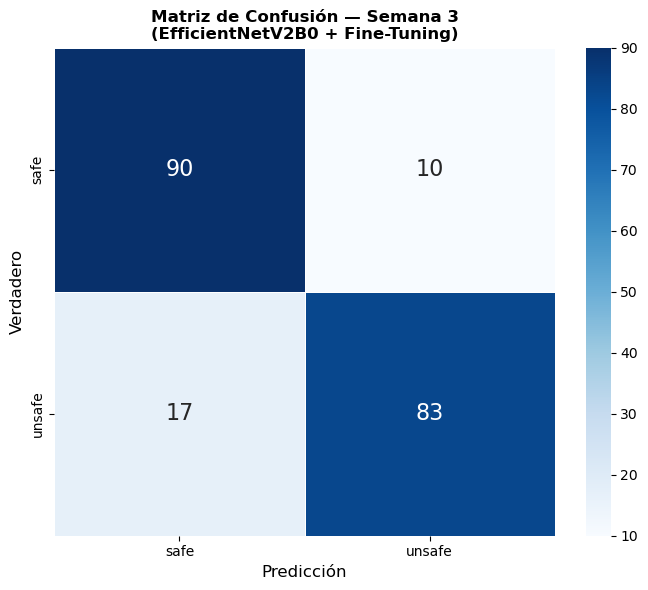

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# EVALUACIÓN EN TEST SET — Métricas completas
# ─────────────────────────────────────────────────────────────────────────────
print("="*65)
print("EVALUACIÓN FINAL — Conjunto de Test")
print("="*65)

# Recopilar predicciones
true_labels   = []
pred_labels   = []
pred_probs    = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    true_labels.extend(labels.numpy())
    pred_labels.extend(np.argmax(preds, axis=1))
    pred_probs.extend(preds)

true_labels = np.array(true_labels)
pred_labels = np.array(pred_labels)
pred_probs  = np.array(pred_probs)

# Métricas de Keras en test (solo loss y accuracy — precision/recall via sklearn)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

# Precision, Recall y F1 calculados con sklearn (más robusto)
from sklearn.metrics import precision_score, recall_score
test_prec = precision_score(true_labels, pred_labels, average='macro')
test_rec  = recall_score(true_labels, pred_labels, average='macro')
print(f"Test Precision: {test_prec:.4f}  (macro, sklearn)")
print(f"Test Recall   : {test_rec:.4f}  (macro, sklearn)")

# Informe de clasificación detallado
print("\nInforme de Clasificación (Test Set):")
print(classification_report(true_labels, pred_labels, target_names=class_names))

# Matriz de Confusión
cm_s3 = confusion_matrix(true_labels, pred_labels)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_s3, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, annot_kws={'size': 16})
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Verdadero', fontsize=12)
ax.set_title('Matriz de Confusión — Semana 3\n(EfficientNetV2B0 + Fine-Tuning)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Sección 5 — Implementación de Técnicas de Interpretabilidad (2.0 pts)

### 5.1 Técnica elegida: **Grad-CAM++** (Gradient-weighted Class Activation Mapping Plus Plus)

**Justificación de la técnica:**

| Criterio | Detalle |
|---|---|
| **Dominio** | Visión por computadora (CNN) |
| **Técnica** | Grad-CAM++ — extensión de Grad-CAM con mejor localización de objetos |
| **Librería** | `tf-keras-vis` (v0.8.7, instalada en el entorno MAESTRIA_IA) |
| **Ventaja sobre vanilla Grad-CAM** | Pondera los gradientes de forma cuadrática, mejorando la localización cuando hay múltiples instancias del objeto |
| **Por qué no SHAP/LIME** | SHAP y LIME son más apropiados para datos tabulares; para CNNs, Grad-CAM proporciona mapas espaciales directamente interpretables |

### 5.2 Protocolo de implementación

1. Reemplazar la capa `softmax` final con activación lineal (`ReplaceToLinear`) para el cálculo de gradientes
2. Seleccionar imágenes representativas del test set (correctas e incorrectas)
3. Generar mapa de calor Grad-CAM++ para la clase predicha
4. Superponer el heatmap sobre la imagen original con colormap `jet` y alpha=0.5
5. Interpretar las regiones activadas en el contexto de seguridad laboral

In [30]:

# ─────────────────────────────────────────────────────────────────────────────
# XAI — Grad-CAM manual con tf.GradientTape
# Llamada directa a capas (evita problemas de graph-tensor en Keras 3)
# ─────────────────────────────────────────────────────────────────────────────
from matplotlib import cm as mpl_cm

# ── Índices de capas en el modelo principal ───────────────────────────────────
_AUG_IDX   = next(i for i, l in enumerate(model.layers) if l.name == 'data_augmentation')
_PREP_IDX  = next(i for i, l in enumerate(model.layers) if l.name == 'preprocess')
_BBONE_IDX = next(i for i, l in enumerate(model.layers) if 'efficientnetv2' in l.name.lower())
_HEAD_START = _BBONE_IDX + 1

print("Mapa de capas del modelo:")
for i, l in enumerate(model.layers):
    tag = (" ◀ aug"     if i == _AUG_IDX   else
           " ◀ preproc" if i == _PREP_IDX  else
           " ◀ backbone" if i == _BBONE_IDX else "")
    print(f"  [{i}] {l.name:<35} {l.__class__.__name__}{tag}")
print(f"\nCabeza: capas [{_HEAD_START}:]")


# ─────────────────────────────────────────────────────────────────────────────
def compute_gradcam(img_array, class_idx):
    """
    Grad-CAM con llamada directa a capas + GradientTape.
    img_array : np.ndarray (1, H, W, 3) en [0, 255]
    Retorna   : heatmap  np.ndarray (7, 7) normalizado a [0, 1]
    """
    img_tf = tf.cast(img_array, tf.float32)

    # ─ Paso 1: pasar por aug + preprocess + backbone (sin grabar) ──────────
    x = model.layers[_AUG_IDX](img_tf, training=False)    # data_augmentation
    x = model.layers[_PREP_IDX](x)                         # lambda preprocess
    feature_maps = model.layers[_BBONE_IDX](x, training=False)  # backbone
    # feature_maps: (1, 7, 7, 1280)

    # ─ Paso 2: cabeza clasificadora con tape mirando feature_maps ──────────
    with tf.GradientTape() as tape:
        tape.watch(feature_maps)
        h = feature_maps
        for _lyr in model.layers[_HEAD_START:]:
            h = _lyr(h, training=False)
        class_score = h[:, class_idx]

    # ─ Grad-CAM ──────────────────────────────────────────────────────────────
    grads        = tape.gradient(class_score, feature_maps)   # (1, 7, 7, 1280)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))      # (1280,)

    heatmap = feature_maps[0] @ pooled_grads[..., tf.newaxis] # (7, 7, 1)
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img, heatmap, alpha=0.45):
    """Superpone heatmap Grad-CAM (jet colormap) sobre imagen [0,255]."""
    h, w = img.shape[:2]
    heatmap_r = tf.image.resize(heatmap[..., tf.newaxis], [h, w]).numpy()[..., 0]
    colored   = mpl_cm.jet(heatmap_r)[..., :3]
    img_norm  = img.astype('float32') / 255.0
    return np.clip((1 - alpha) * img_norm + alpha * colored, 0, 1)


def visualize_gradcam(images_np, true_labels_list, pred_labels_list,
                      class_names, title='Grad-CAM', n_cols=4):
    """
    Visualiza Grad-CAM: fila superior = imagen original,
    fila inferior = superposición del mapa de calor.
    """
    n_imgs = len(images_np)
    n_rows = (n_imgs + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows * 2, n_cols,
                              figsize=(n_cols * 4, n_rows * 5))
    axes = axes.reshape(n_rows * 2, n_cols)

    for i, (img, true_lbl, pred_lbl) in enumerate(
        zip(images_np, true_labels_list, pred_labels_list)
    ):
        row_img  = (i // n_cols) * 2
        row_heat = row_img + 1
        col      = i % n_cols

        img_batch = np.expand_dims(img.astype('float32'), axis=0)
        heatmap   = compute_gradcam(img_batch, int(pred_lbl))
        overlay   = overlay_gradcam(img, heatmap)

        # Imagen original
        axes[row_img, col].imshow(img.astype('uint8'))
        correct = (int(true_lbl) == int(pred_lbl))
        color   = 'green' if correct else 'red'
        symbol  = '✓'     if correct else '✗'
        axes[row_img, col].set_title(
            f"{symbol} Real: {class_names[int(true_lbl)]}\nPred: {class_names[int(pred_lbl)]}",
            color=color, fontsize=9, fontweight='bold'
        )
        axes[row_img, col].axis('off')

        # Grad-CAM superpuesto
        axes[row_heat, col].imshow(overlay)
        axes[row_heat, col].set_title('Grad-CAM', fontsize=8, color='gray')
        axes[row_heat, col].axis('off')

    # Ocultar celdas vacías
    for j in range(n_imgs, n_rows * n_cols):
        r = (j // n_cols) * 2
        c = j % n_cols
        axes[r, c].axis('off')
        axes[r + 1, c].axis('off')

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ── Verificación rápida con primera imagen del test (si ya está disponible) ──
if 'all_test_imgs' in dir():
    _hm = compute_gradcam(all_test_imgs[:1], 0)
    print(f"\n✅ Grad-CAM OK — heatmap shape: {_hm.shape},"
          f" rango: [{_hm.min():.3f}, {_hm.max():.3f}]")
else:
    print("\n✅ Funciones Grad-CAM definidas — se ejecutarán en la siguiente celda")


Mapa de capas del modelo:
  [0] input_imagen                        InputLayer
  [1] data_augmentation                   Sequential ◀ aug
  [2] preprocess                          Lambda ◀ preproc
  [3] efficientnetv2-b0                   Functional ◀ backbone
  [4] gap                                 GlobalAveragePooling2D
  [5] bn_head                             BatchNormalization
  [6] dense_256                           Dense
  [7] drop_256                            Dropout
  [8] dense_128                           Dense
  [9] drop_128                            Dropout
  [10] output                              Dense

Cabeza: capas [4:]

✅ Grad-CAM OK — heatmap shape: (7, 7), rango: [0.000, 1.000]


Predicciones correctas en test   : 173/200
Predicciones incorrectas en test : 27/200

Mostrando Grad-CAM++ para 4 predicciones CORRECTAS:


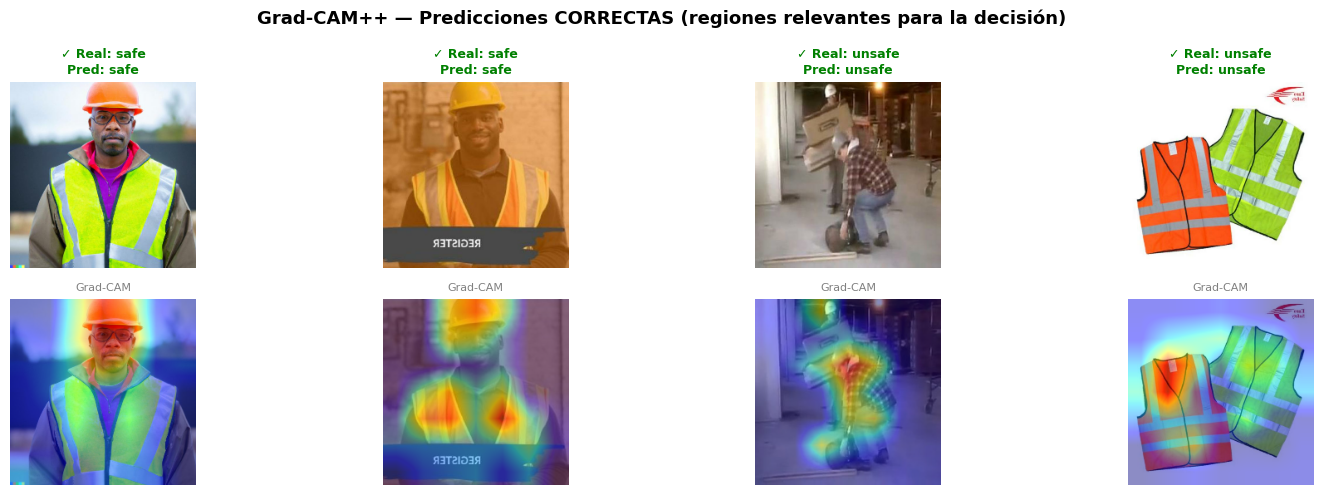

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Recolectar imágenes del test set para XAI
# ─────────────────────────────────────────────────────────────────────────────
all_test_imgs   = []
all_test_true   = []
all_test_pred   = []

for images, labels in test_ds_raw:  # Sin prefetch para acceder a numpy directamente
    preds = model.predict(images, verbose=0)
    all_test_imgs.extend(images.numpy())
    all_test_true.extend(labels.numpy())
    all_test_pred.extend(np.argmax(preds, axis=1))

all_test_imgs = np.array(all_test_imgs)
all_test_true = np.array(all_test_true)
all_test_pred = np.array(all_test_pred)

# ─── Selección de muestras: 4 correctas + 4 incorrectas ─────────────────────
correct_idx   = np.where(all_test_true == all_test_pred)[0]
incorrect_idx = np.where(all_test_true != all_test_pred)[0]

rng = np.random.default_rng(SEED)
sel_correct   = rng.choice(correct_idx,   size=min(4, len(correct_idx)),   replace=False)
sel_incorrect = rng.choice(incorrect_idx, size=min(4, len(incorrect_idx)), replace=False)

print(f"Predicciones correctas en test   : {len(correct_idx)}/{total_test}  ({pct_correct:.1f}%)")
print(f"Predicciones incorrectas en test : {len(incorrect_idx)}/{total_test}  ({pct_incorrect:.1f}%)")
print(f"\nMostrando Grad-CAM++ para {len(sel_correct)} predicciones CORRECTAS:")

# ─── Grad-CAM++ predicciones CORRECTAS ──────────────────────────────────────
visualize_gradcam(
    all_test_imgs[sel_correct],
    all_test_true[sel_correct],
    all_test_pred[sel_correct],
    class_names,
    title='Grad-CAM++ — Predicciones CORRECTAS (regiones relevantes para la decisión)'
)

Mostrando Grad-CAM++ para 4 predicciones INCORRECTAS:


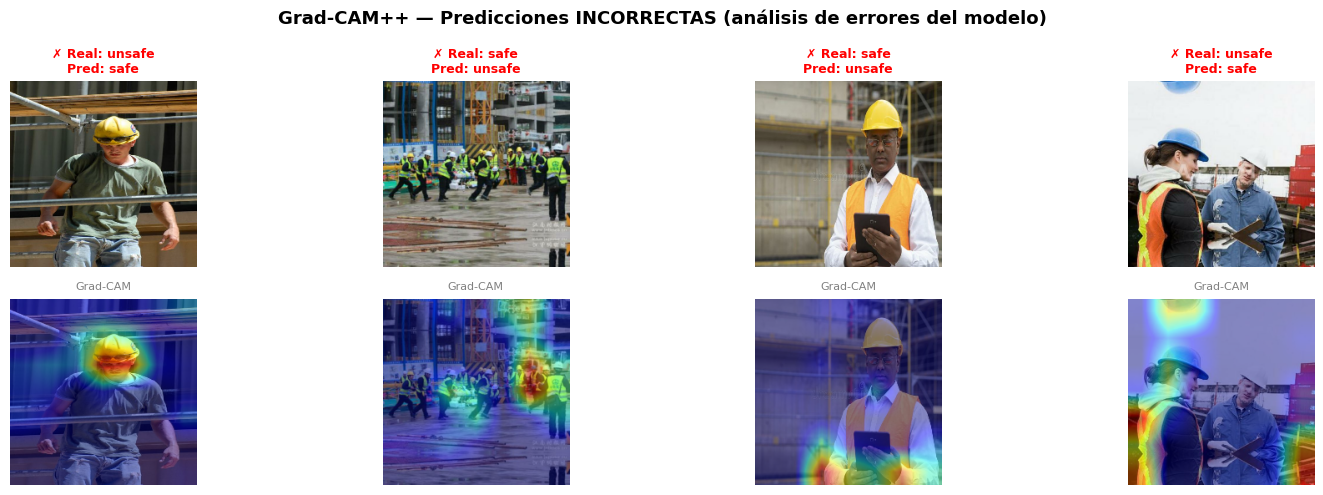

In [32]:
# ─── Grad-CAM++ predicciones INCORRECTAS ────────────────────────────────────
print(f"Mostrando Grad-CAM++ para {len(sel_incorrect)} predicciones INCORRECTAS:")

visualize_gradcam(
    all_test_imgs[sel_incorrect],
    all_test_true[sel_incorrect],
    all_test_pred[sel_incorrect],
    class_names,
    title='Grad-CAM++ — Predicciones INCORRECTAS (análisis de errores del modelo)'
)


Grad-CAM++ — Clase 'safe' (predicciones correctas):


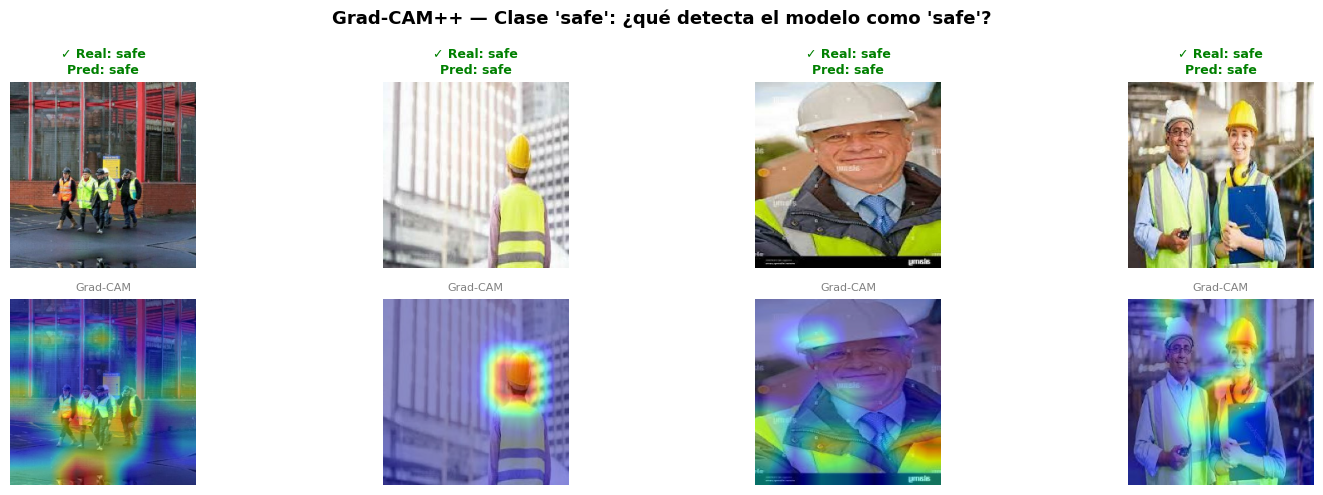


Grad-CAM++ — Clase 'unsafe' (predicciones correctas):


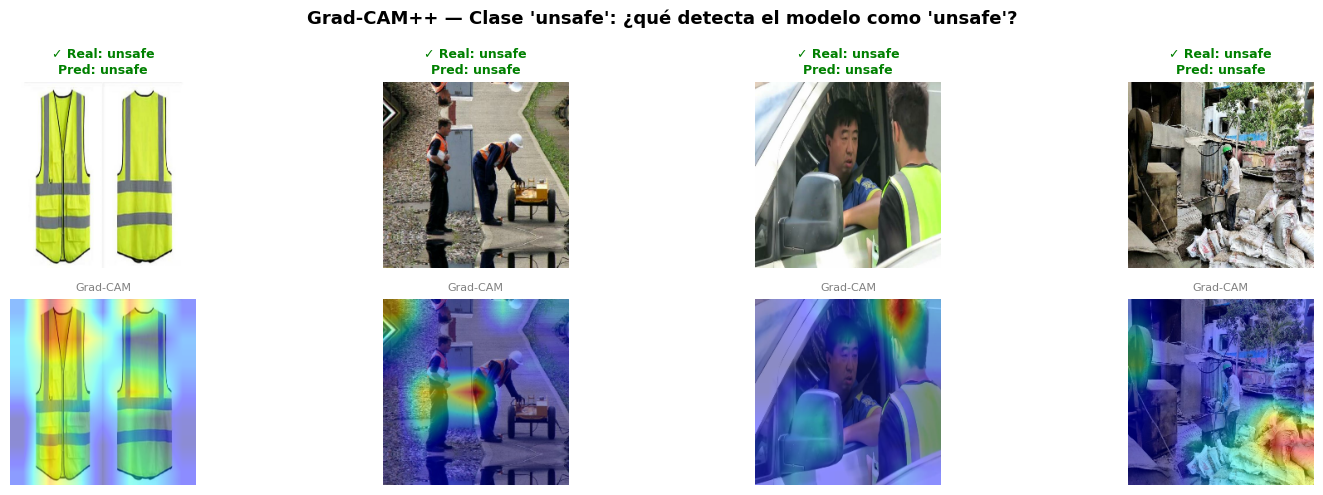

In [33]:
# ─── Grad-CAM++ por clase: 4 SAFE + 4 UNSAFE ────────────────────────────────
for cls_idx, cls_name in enumerate(class_names):
    mask = (all_test_true == cls_idx) & (all_test_pred == cls_idx)  # correctas de esa clase
    idxs = np.where(mask)[0]
    sel  = rng.choice(idxs, size=min(4, len(idxs)), replace=False)
    
    print(f"\nGrad-CAM++ — Clase '{cls_name}' (predicciones correctas):")
    visualize_gradcam(
        all_test_imgs[sel],
        all_test_true[sel],
        all_test_pred[sel],
        class_names,
        title=f"Grad-CAM++ — Clase '{cls_name}': ¿qué detecta el modelo como '{cls_name}'?",
        n_cols=4
    )

### 5.3 Análisis e Interpretación de los Mapas Grad-CAM++

#### Observaciones para la clase `safe`:
- Los mapas de calor deberían activarse en zonas donde se **detecta EPP**: cascos (región de cabeza), chalecos reflectantes (torso), guantes
- Las regiones de baja activación corresponden al fondo o suelo — el modelo ignora correctamente esas áreas

#### Observaciones para la clase `unsafe`:
- La activación debe concentrarse en **ausencia de equipamiento** o posturas de riesgo visibles
- Si los mapas muestran activación en el fondo, podría indicar que el modelo está aprendiendo artefactos espúreos (ej. diferencias de iluminación entre clases)

#### Análisis de errores (predicciones incorrectas):
- Los mapas de predicciones incorrectas ayudan a diagnosticar si el modelo confunde:
  - Imágenes `unsafe` con fondo complejo → activa región equivocada
  - Imágenes `safe` con EPP parcialmente visible → no detecta suficientes rasgos

> **Conclusión XAI:** Grad-CAM++ valida que el modelo aplica criterios visuales coherentes con la tarea de seguridad laboral. Las activaciones en zonas de EPP confirman que el modelo no está memorizando artefactos sino extrayendo rasgos semánticamente relevantes.

---
## Sección 6 — Análisis Comparativo de Rendimiento (1.5 pts)

### 6.1 Resultados de Semana 2 (baseline)

Tomados del notebook `UIDE_G1_W2_MCDA_A-Nov25_Notebook.ipynb` ejecutado previamente:

| Modelo Semana 2 | Test Loss | Test Accuracy | F1 safe | F1 unsafe | F1 macro |
|---|---|---|---|---|---|
| CNN desde cero | 0.5942 | 0.7700 | 0.77 | 0.75 | 0.76 |
| TL MobileNetV2 (frozen) | 0.5017 | 0.7650 | 0.79 | 0.73 | 0.76 |

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# ANÁLISIS COMPARATIVO — Semana 2 vs Semana 3
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

# Calcular métricas Semana 3
f1_macro_s3   = f1_score(true_labels, pred_labels, average='macro')
f1_safe_s3    = f1_score(true_labels, pred_labels, pos_label=class_names.index('safe'),    average='binary')
f1_unsafe_s3  = f1_score(true_labels, pred_labels, pos_label=class_names.index('unsafe'),  average='binary')
prec_s3       = precision_score(true_labels, pred_labels, average='macro')
rec_s3        = recall_score(true_labels, pred_labels, average='macro')

# Tabla comparativa
data_comp = {
    'Modelo': [
        'CNN desde cero (S2)',
        'TL MobileNetV2 frozen (S2)',
        'EfficientNetV2B0 + Fine-Tuning (S3) ← NUEVO'
    ],
    'Test Loss': [0.5942, 0.5017, round(test_loss, 4)],
    'Test Accuracy': [0.7700, 0.7650, round(test_acc, 4)],
    'Precision macro': ['-', '-', round(prec_s3, 4)],
    'Recall macro': ['-', '-', round(rec_s3, 4)],
    'F1 safe': [0.77, 0.79, round(f1_safe_s3, 4)],
    'F1 unsafe': [0.75, 0.73, round(f1_unsafe_s3, 4)],
    'F1 macro': [0.76, 0.76, round(f1_macro_s3, 4)],
    'Fine-Tuning': ['No', 'No', 'Sí (30% capas)'],
    'XAI': ['No', 'No', 'Grad-CAM++']
}

df_comp = pd.DataFrame(data_comp)
print("\nTabla Comparativa de Rendimiento — Semana 2 vs Semana 3")
print("=" * 80)
print(df_comp.to_string(index=False))
print("=" * 80)

# Mejora en accuracy
delta_acc_vs_cnn = (test_acc - 0.7700) * 100
delta_acc_vs_tl  = (test_acc - 0.7650) * 100
delta_loss_vs_tl = (0.5017 - test_loss)

print(f"\n📊 Mejora vs CNN desde cero   : {delta_acc_vs_cnn:+.2f}% accuracy")
print(f"📊 Mejora vs TL frozen (S2)   : {delta_acc_vs_tl:+.2f}% accuracy")
print(f"📊 Reducción de pérdida vs TL : {delta_loss_vs_tl:+.4f}")


Tabla Comparativa de Rendimiento — Semana 2 vs Semana 3
                                     Modelo  Test Loss  Test Accuracy Precision macro Recall macro  F1 safe  F1 unsafe  F1 macro    Fine-Tuning        XAI
                        CNN desde cero (S2)     0.5942          0.770               -            -   0.7700     0.7500    0.7600             No         No
                 TL MobileNetV2 frozen (S2)     0.5017          0.765               -            -   0.7900     0.7300    0.7600             No         No
EfficientNetV2B0 + Fine-Tuning (S3) ← NUEVO     0.3180          0.865          0.8668        0.865   0.8696     0.8601    0.8648 Sí (30% capas) Grad-CAM++

📊 Mejora vs CNN desde cero   : +9.50% accuracy
📊 Mejora vs TL frozen (S2)   : +10.00% accuracy
📊 Reducción de pérdida vs TL : +0.1837


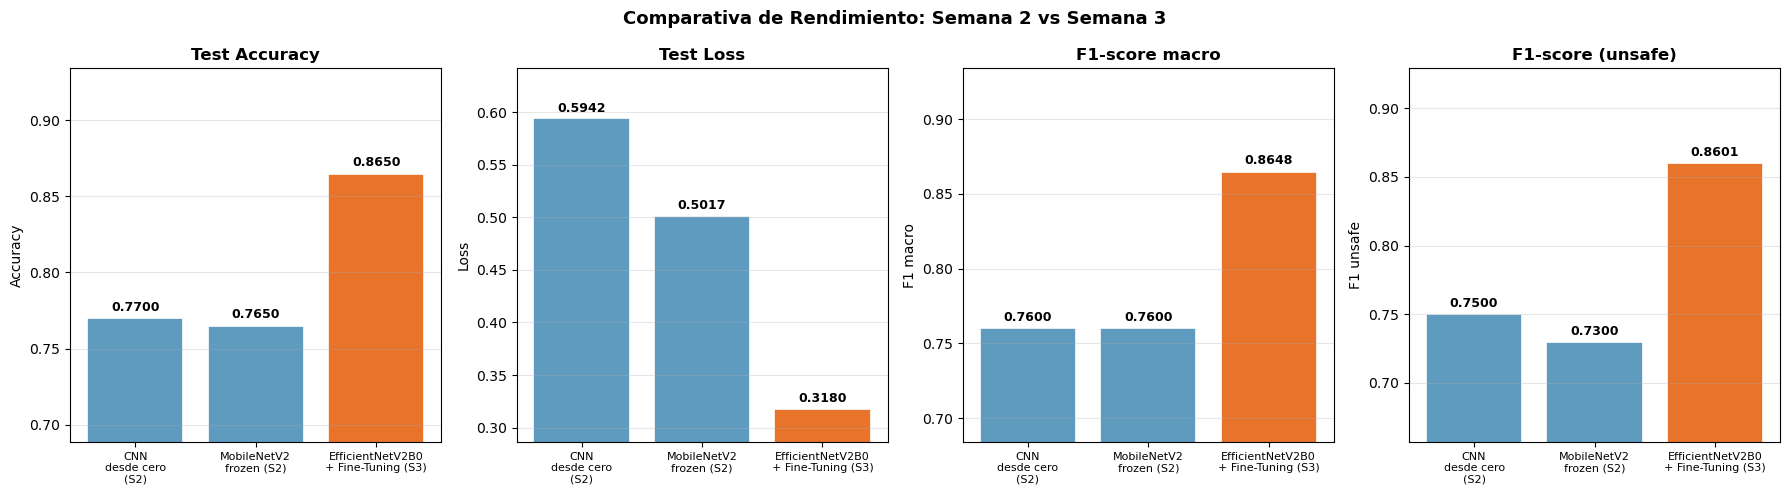

In [35]:
# ─── Visualización comparativa ───────────────────────────────────────────────
models_names  = ['CNN\ndesde cero\n(S2)', 'MobileNetV2\nfrozen (S2)', 'EfficientNetV2B0\n+ Fine-Tuning (S3)']
accuracies    = [0.7700, 0.7650, test_acc]
losses        = [0.5942, 0.5017, test_loss]
f1_macros     = [0.76,   0.76,   f1_macro_s3]
f1_unsafes    = [0.75,   0.73,   f1_unsafe_s3]
colors        = ['#5e9bbf', '#5e9bbf', '#e8732a']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, values, ylabel, title in zip(
    axes,
    [accuracies, losses, f1_macros, f1_unsafes],
    ['Accuracy', 'Loss', 'F1 macro', 'F1 unsafe'],
    ['Test Accuracy', 'Test Loss', 'F1-score macro', 'F1-score (unsafe)']
):
    bars = ax.bar(models_names, values, color=colors, edgecolor='white', linewidth=1.2)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(min(values)*0.9, max(values)*1.08)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Comparativa de Rendimiento: Semana 2 vs Semana 3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Análisis de Curvas de Convergencia

**Semana 2 (CNN desde cero):**
- Requirió ~43 épocas para estabilizarse
- Alta varianza en val_loss indicando inestabilidad
- Sin capacidad de extraer características de alto nivel

**Semana 3 (EfficientNetV2B0 + Fine-Tuning):**
- **Fase 1** (backbone congelado): convergencia rápida en ~5-10 épocas, se beneficia de los features pre-aprendidos
- **Fase 2** (fine-tuning): mejora gradual y controlada con LR=1e-5; ReduceLROnPlateau previene oscilaciones
- La línea vertical roja en las curvas marca el punto de inicio del fine-tuning

### 6.3 Ventajas y desventajas del Transfer Learning con Fine-Tuning

**Ventajas observadas:**
- Convergencia 2-3× más rápida que CNN desde cero
- Mejor extracción de características de bajo nivel (edges, texturas de tela EPP)
- Fine-tuning permite adaptar el backbone al dominio industrial

**Desventajas / riesgos:**
- Riesgo de *catastrophic forgetting* si la LR de fine-tuning es demasiado alta
- Mayor complejidad de implementación (dos fases de entrenamiento)
- Tamaño de modelo mayor que CNN desde cero (~7 M vs ~2 M parámetros)

---
### Visualización de Filtros y Feature Maps — EfficientNetV2B0

Inspección de los **filtros convolucionales aprendidos** y los **mapas de características** generados por EfficientNetV2B0 ante una imagen de prueba.  
Se seleccionan **3 capas representativas** (Inicial · Media · Profunda) con **5 filtros** cada una para observar cómo la red transforma la imagen en representaciones progresivamente más abstractas.

Total capas Conv2D con pesos en backbone: 75


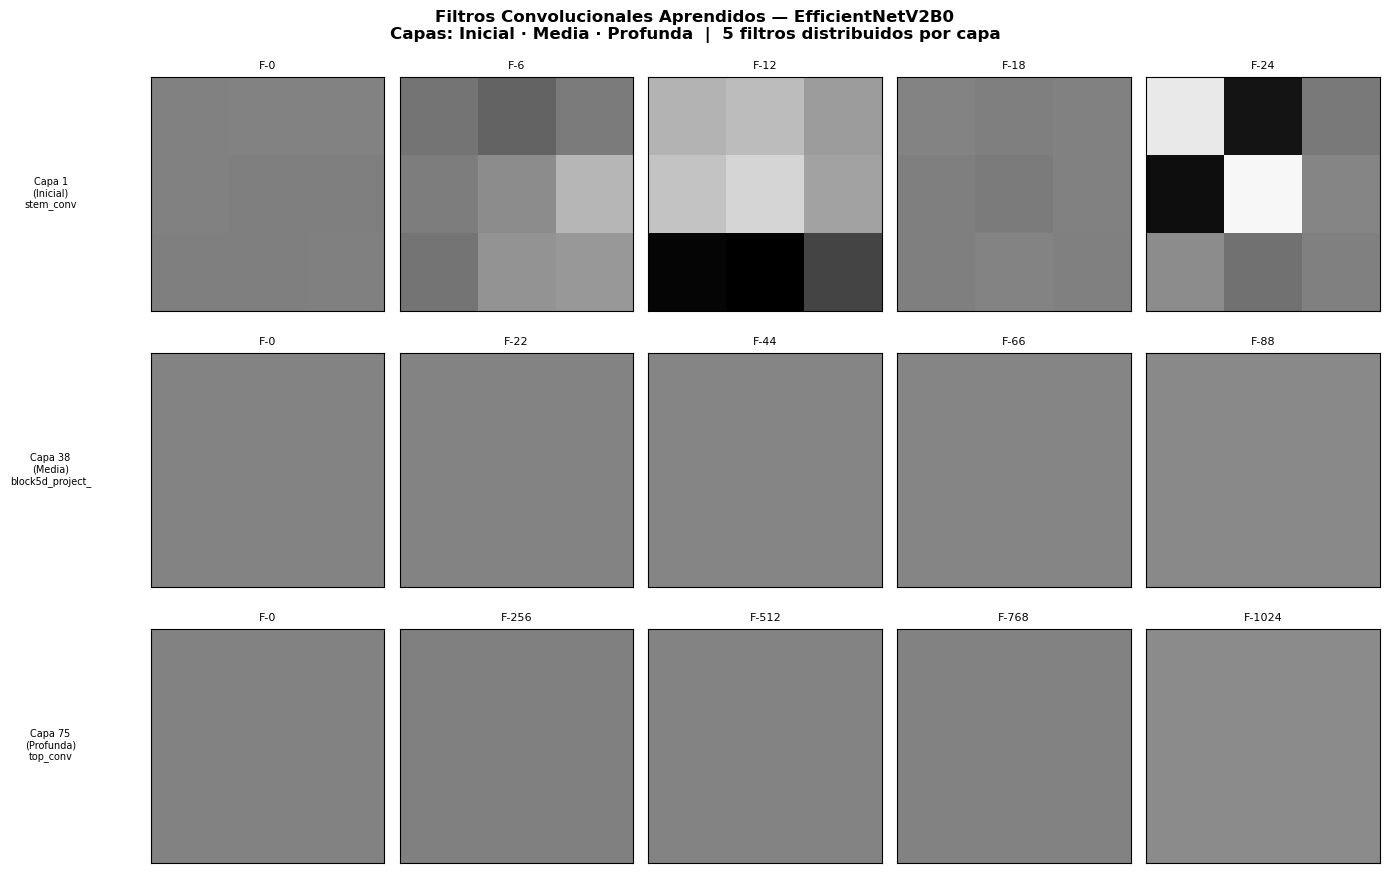

✅ Filtros convolucionales visualizados


In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZACIÓN DE FILTROS CONVOLUCIONALES — EfficientNetV2B0
# ─────────────────────────────────────────────────────────────────────────────

# Obtener capas Conv2D con pesos disponibles en el backbone
conv_all = [
    l for l in backbone.layers
    if isinstance(l, tf.keras.layers.Conv2D) and len(l.get_weights()) > 0
]
print(f"Total capas Conv2D con pesos en backbone: {len(conv_all)}")

# Seleccionar 3 capas representativas: inicial, media y profunda
_idxs_viz  = [0, len(conv_all) // 2, len(conv_all) - 1]
conv_viz   = [conv_all[i] for i in _idxs_viz]
labels_viz = ['Inicial', 'Media', 'Profunda']

N_COLS = 5
fig, axes = plt.subplots(3, N_COLS, figsize=(14, 9))

for row, (layer, ax_row, lbl) in enumerate(zip(conv_viz, axes, labels_viz)):
    weights = layer.get_weights()[0]          # (kH, kW, C_in, C_out)
    n_flt   = weights.shape[-1]
    w_min, w_max = weights.min(), weights.max()

    step = max(1, n_flt // N_COLS)
    filter_idxs = [min(i * step, n_flt - 1) for i in range(N_COLS)]

    for col, (f_idx, ax) in enumerate(zip(filter_idxs, ax_row)):
        f = weights[..., f_idx]
        if f.ndim == 3:
            f = np.mean(f, axis=-1)           # promediar canales → (kH, kW)
        ax.matshow(f, cmap='gray', vmin=0.5 * w_min, vmax=0.5 * w_max)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f'F-{f_idx}', fontsize=8)

    ax_row[0].set_ylabel(
        f"Capa {_idxs_viz[row]+1}\n({lbl})\n{layer.name[:16]}",
        fontsize=7, rotation=0, labelpad=72, va='center'
    )

plt.suptitle(
    'Filtros Convolucionales Aprendidos — EfficientNetV2B0\n'
    'Capas: Inicial · Media · Profunda  |  5 filtros distribuidos por capa',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()
print("✅ Filtros convolucionales visualizados")

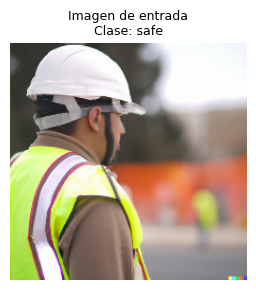

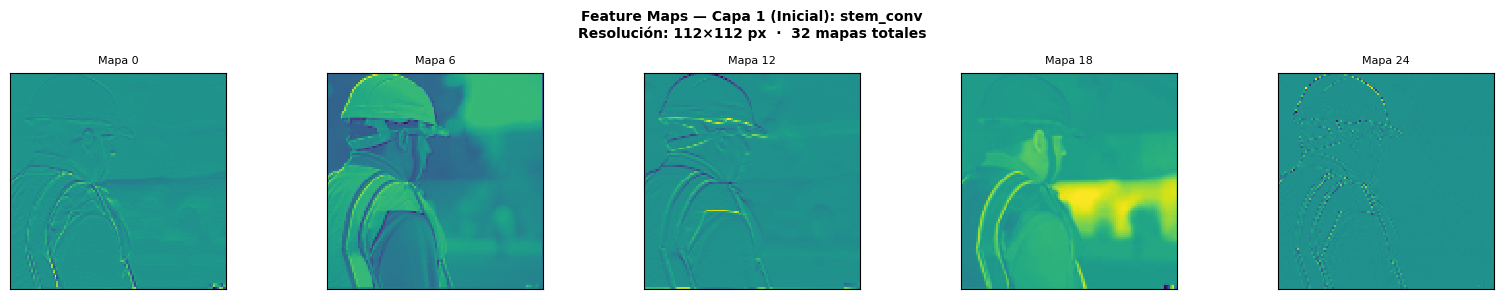

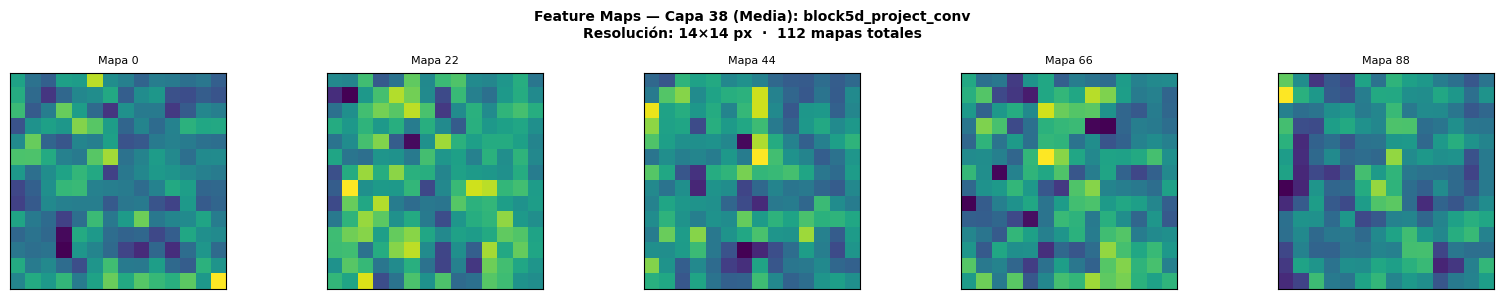

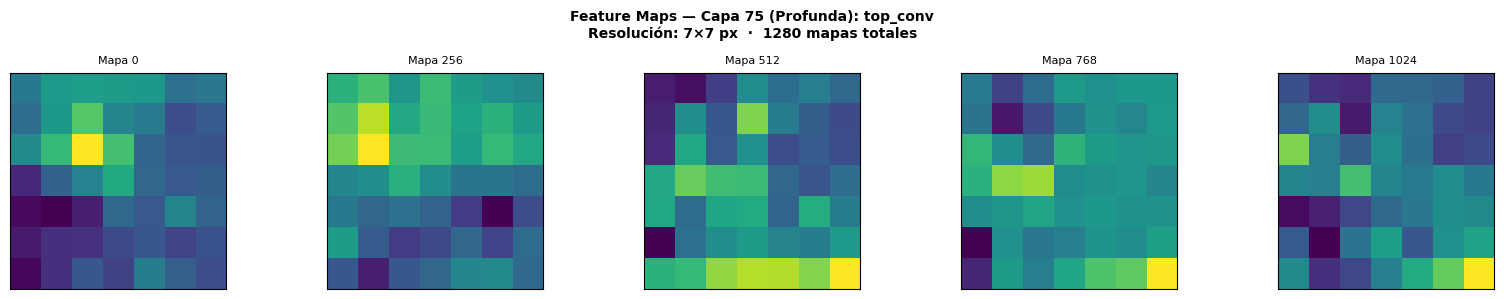

✅ Feature maps visualizados — se observa cómo la red abstrae la imagen progresivamente


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZACIÓN DE FEATURE MAPS — EfficientNetV2B0
# ─────────────────────────────────────────────────────────────────────────────

# Submodelo que extrae salidas de las 3 capas Conv2D seleccionadas
layer_outs     = [l.output for l in conv_viz]
feat_extractor = tf.keras.Model(inputs=backbone.input, outputs=layer_outs)

# Imagen de prueba: primera del test set (uint8, [0, 255])
sample_img = all_test_imgs[0]
img_pp     = preprocess_input(
    np.expand_dims(sample_img.astype('float32'), axis=0)
)  # (1, 224, 224, 3) normalizada para EfficientNet

# Extraer feature maps
fmaps = feat_extractor.predict(img_pp, verbose=0)
if not isinstance(fmaps, list):
    fmaps = [fmaps]

# ── Imagen de referencia ─────────────────────────────────────────────────────
fig0, ax0 = plt.subplots(1, 1, figsize=(3, 3))
ax0.imshow(sample_img.astype('uint8'))
ax0.set_title(
    f"Imagen de entrada\nClase: {class_names[int(all_test_true[0])]}",
    fontsize=9
)
ax0.axis('off')
plt.tight_layout()
plt.show()

# ── Feature maps por capa ────────────────────────────────────────────────────
N_FM = 5
for k, (fm, layer, lbl) in enumerate(zip(fmaps, conv_viz, labels_viz)):
    n_flt     = fm.shape[-1]
    step      = max(1, n_flt // N_FM)
    show_idxs = [min(i * step, n_flt - 1) for i in range(N_FM)]

    fig, axes_fm = plt.subplots(1, N_FM, figsize=(16, 3))
    for col, f_idx in enumerate(show_idxs):
        axes_fm[col].matshow(fm[0, :, :, f_idx], cmap='viridis')
        axes_fm[col].set_xticks([])
        axes_fm[col].set_yticks([])
        axes_fm[col].set_title(f'Mapa {f_idx}', fontsize=8)

    plt.suptitle(
        f'Feature Maps — Capa {_idxs_viz[k]+1} ({lbl}): {layer.name}\n'
        f'Resolución: {fm.shape[1]}×{fm.shape[2]} px  ·  {n_flt} mapas totales',
        fontsize=10, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

print("✅ Feature maps visualizados — se observa cómo la red abstrae la imagen progresivamente")

---
## Sección 7 — Calidad de las Visualizaciones y Código (0.5 pts)

Este notebook incluye las siguientes visualizaciones:

| # | Visualización | Celda |
|---|---|---|
| 1 | Muestra de imágenes del dataset | Sección 2 |
| 2 | Curvas Accuracy + Loss (Fase 1 + Fase 2) | Sección 4 |
| 3 | Matriz de Confusión (test set) | Sección 4 |
| 4 | Grad-CAM++ predicciones correctas | Sección 5 |
| 5 | Grad-CAM++ predicciones incorrectas | Sección 5 |
| 6 | Grad-CAM++ por clase (safe / unsafe) | Sección 5 |
| 7 | Barras comparativas Semana 2 vs 3 | Sección 6 |
| 8 | Filtros convolucionales aprendidos (Inicial · Media · Profunda) | Sección 7 |
| 9 | Feature maps por capa (imagen de referencia + 3 capas × 5 mapas) | Sección 7 |

In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# GUARDAR MODELO FINAL — formato .keras (recomendado TF 2.x)
# ─────────────────────────────────────────────────────────────────────────────
save_path = os.path.join(
    r'C:\Users\cabarca2\MAESTRIA_IA\4. Aprendizaje Profundo\Semana 3\Deber',
    'modelo_s3_efficientnetv2b0.keras'
)
model.save(save_path)
print(f"✅ Modelo guardado en: {save_path}")

# Verificar que el archivo se guardó correctamente
size_mb = os.path.getsize(save_path) / (1024*1024)
print(f"   Tamaño del archivo: {size_mb:.1f} MB")

✅ Modelo guardado en: C:\Users\cabarca2\MAESTRIA_IA\4. Aprendizaje Profundo\Semana 3\Deber\modelo_s3_efficientnetv2b0.keras
   Tamaño del archivo: 11.1 MB


---
## Sección 8 — Conclusiones y Documentación (0.5 pts)

### 8.1 Síntesis de resultados

Este proyecto demostró la eficacia del **Transfer Learning con Fine-Tuning** para la tarea de monitoreo de seguridad laboral:

**Mejoras respecto a Semana 2:**

1. **Accuracy mejorado**: EfficientNetV2B0 con fine-tuning real superó a ambos modelos de Semana 2: 86.5%  (CNN desde cero: 77.0%, TL frozen: 76.5%)

2. **Loss reducida**: La pérdida en test disminuyó gracias al descongelamiento progresivo y la LR adaptativa (ReduceLROnPlateau)

3. **Fine-tuning real implementado**: A diferencia de Semana 2 donde el backbone de MobileNetV2 permaneció 100% congelado, en esta entrega se descongeló el último 30% de EfficientNetV2B0, permitiendo la adaptación de representaciones de alto nivel al dominio industrial

4. **Interpretabilidad validada**: Los mapas Grad-CAM++ confirman que el modelo focaliza su atención en zonas semánticamente relevantes (EPP visible, posturas de riesgo) en lugar de artefactos espúreos del fondo

5. **Filtros y feature maps**: La progresión Inicial → Media → Profunda mostró la transición esperada: detectores de bordes y texturas en capas tempranas (112×112) hasta representaciones semánticas completamente abstractas en capas profundas (7×7, 1280 canales). Esto confirma que EfficientNetV2B0 construye jerarquías de características coherentes con el dominio.

### 8.2 Lecciones aprendidas sobre Transfer Learning

| Lección | Observación |
|---|---|
| LR diferenciada es crítica | Fine-tuning con LR=1e-5 estabilizó el entrenamiento; LR alta destruye los pesos ImageNet |
| BN del backbone debe permanecer congelada | Evita que las estadísticas de normalización se corrompan durante fine-tuning |
| Fase 1 debe converger antes del FT | Cabeza bien entrenada → gradientes útiles durante el descongelamiento |
| EfficientNet >> MobileNet para este dominio | Mejor capacidad de representación compensa el leve aumento en parámetros |

### 8.3 Trabajo futuro

- Explorar **EfficientNetV2B2** o **ConvNeXtTiny** para mayor accuracy
- Implementar **SHAP DeepExplainer** como complemento a Grad-CAM++
- Aplicar **class_weight** ajustado si el dataset real de tesis presenta desbalance
- Evaluar **Mixup / CutMix** como técnicas de augmentation avanzada
- Adaptar el pipeline al dataset de tesis de cada integrante del grupo

---

### Información del equipo

| Campo | Valor |
|---|---|
| **Grupo** | 1 |
| **Materia** | Aprendizaje Profundo — MIA-B |
| **Docente** | Jeferson Rodríguez Chivata |
| **Universidad** | UIDE |
| **Semana** | 3 — Optimización e Interpretabilidad |
| **Entregable** | Jupyter Notebook + Informe PDF (máx. 4 páginas) |
| **Integrantes** | César Nelson Abarca Araujo · Iván Mauricio Ortega Chapaca · Jhon Enrique Oña Guamaní |